In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ВХІДНІ ДАНІ (Варіант 5)
# ==============================================================================
k_var = 5
n_idx = np.array([1, 2, 3, 4, 5, 6])
y = np.array([2.0, 1.0, 2.0, 1.0, 3.0, 4.0])
N = len(y)

print("=" * 65)
print(f"ЛАБОРАТОРНА РОБОТА №2 (Варіант {k_var})")
print("=" * 65)


ЛАБОРАТОРНА РОБОТА №2 (Варіант 5)


In [ ]:
# ЧАСТИНА 1: Апроксимація періодичного сигналу рядом Фур'є
# ==============================================================================
# a_0 розраховується за формулою (42)
a0 = (2.0 / N) * np.sum(y)

# Гармоніки k = 1, 2, 3
K = N // 2
a_k = np.zeros(K)
b_k = np.zeros(K)

for m in range(1, K + 1):
    # tn = n * Ta = n * (2*pi / (N*omega_0)) => m * omega_0 * tn = m * 2*pi*n / N
    arg = m * 2.0 * np.pi * n_idx / N
    a_k[m - 1] = (2.0 / N) * np.sum(y * np.cos(arg))
    b_k[m - 1] = (2.0 / N) * np.sum(y * np.sin(arg))

print("\n--- 1. КОЕФІЦІЄНТИ РЯДУ ФУР'Є ---")
print(f"a0 = {a0:.4f} (постійна складова a0/2 = {a0/2:.4f})")
for m in range(1, K + 1):
    print(f"Гармоніка {m}: a_{m} = {a_k[m-1]:.4f},  b_{m} = {b_k[m-1]:.4f}")

# Функція відновлення сигналу за рядом Фур'є
# Приймає нормалізований час theta = omega_0 * t
def fourier_series(theta):
    res = a0 / 2.0
    for m in range(1, K + 1):
        res += a_k[m - 1] * np.cos(m * theta) + b_k[m - 1] * np.sin(m * theta)
    return res


--- 1. КОЕФІЦІЄНТИ РЯДУ ФУР'Є ---
a0 = 4.3333 (постійна складова a0/2 = 2.1667)
Гармоніка 1: a_1 = 1.1667,  b_1 = -0.2887
Гармоніка 2: a_2 = 0.8333,  b_2 = -0.2887
Гармоніка 3: a_3 = -0.3333,  b_3 = 0.0000


In [ ]:
# ==============================================================================
# ЧАСТИНА 2: Експоненціальна апроксимація f(x) = exp(A + B*x)
# ==============================================================================
# x_n = 0.1 * k * n = 0.5 * n
x_exp = 0.1 * k_var * n_idx
y_log = np.log(y)

# Розрахунок коефіцієнтів A та B через систему нормальних рівнянь (вирази 54-56)
M_exp = np.array([
    [N, np.sum(x_exp)],
    [np.sum(x_exp), np.sum(x_exp**2)]
])
V_exp = np.array([
    np.sum(y_log),
    np.sum(x_exp * y_log)
])

# Розв'язок СЛАР відносно [A, B]
A_man, B_man = np.linalg.solve(M_exp, V_exp)

# Перевірка через np.polyfit 1-го степеня для логарифмованих значень
B_fit, A_fit = np.polyfit(x_exp, y_log, deg=1)

print("\n--- 2. ЕКСПОНЕНЦІАЛЬНА АПРОКСИМАЦІЯ ---")
print(f"x_n = {x_exp}")
print(f"y_n* = ln(y_n) = {np.round(y_log, 4)}")
print(f"Аналітичний розрахунок: A = {A_man:.4f}, B = {B_man:.4f}")
print(f"Рівняння функції:       f(x) = exp({A_man:.4f} + {B_man:.4f}*x) = {np.exp(A_man):.4f} * exp({B_man:.4f}*x)")
print(f"Перевірка np.polyfit:  A = {A_fit:.4f}, B = {B_fit:.4f}")



--- 2. ЕКСПОНЕНЦІАЛЬНА АПРОКСИМАЦІЯ ---
x_n = [0.5 1.  1.5 2.  2.5 3. ]
y_n* = ln(y_n) = [0.6931 0.     0.6931 0.     1.0986 1.3863]
Аналітичний розрахунок: A = 0.0384, B = 0.3468
Рівняння функції:       f(x) = exp(0.0384 + 0.3468*x) = 1.0391 * exp(0.3468*x)
Перевірка np.polyfit:  A = 0.0384, B = 0.3468


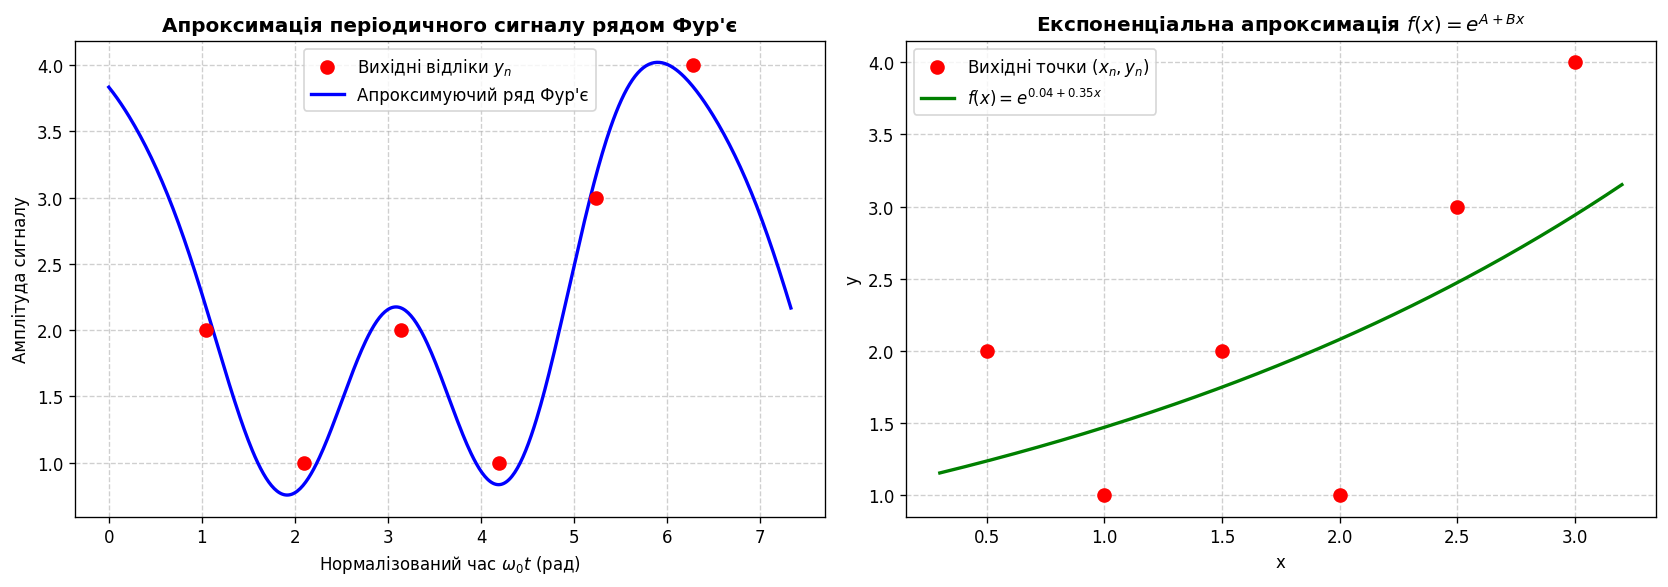

In [ ]:
# ==============================================================================
# ЧАСТИНА 3: Побудова графіків
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Графік 1: Ряд Фур'є (періодичний сигнал)
# Дискретні точки відповідають theta_n = 2*pi*n / N
theta_nodes = 2.0 * np.pi * n_idx / N
theta_dense = np.linspace(0, 2.0 * np.pi * (N + 1) / N, 500)
y_fourier_dense = fourier_series(theta_dense)

ax1.scatter(theta_nodes, y, color='red', s=60, zorder=5, label='Вихідні відліки $y_n$')
ax1.plot(theta_dense, y_fourier_dense, 'b-', linewidth=2, label="Апроксимуючий ряд Фур'є")
ax1.set_title("Апроксимація періодичного сигналу рядом Фур'є", fontweight='bold')
ax1.set_xlabel(r'Нормалізований час $\omega_0 t$ (рад)')
ax1.set_ylabel('Амплітуда сигналу')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Графік 2: Експоненціальна функція
x_dense = np.linspace(x_exp[0] - 0.2, x_exp[-1] + 0.2, 300)
y_exp_dense = np.exp(A_man + B_man * x_dense)

ax2.scatter(x_exp, y, color='red', s=60, zorder=5, label='Вихідні точки ($x_n, y_n$)')
ax2.plot(x_dense, y_exp_dense, 'g-', linewidth=2, label=f'$f(x) = e^{{{A_man:.2f} + {B_man:.2f}x}}$')
ax2.set_title('Експоненціальна апроксимація $f(x) = e^{A+Bx}$', fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('lab2_plot.png', dpi=300)
plt.show()

<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1077/3968621040.py:100: SyntaxWarning: invalid escape sequence '\c'
  ax2.plot(x_dense, y_exp_dense, 'g-', linewidth=2.2, label=f'$f(x) = {np.exp(A_man):.3f} \cdot e^{{{B_man:.3f}x}}$')


=== КОЕФІЦІЄНТИ РЯДУ ФУР'Є ===
a0 = 4.3333 (постійна складова a0/2 = 2.1667)

Варіант А (буквально за формулою (48) методички):
  Гармоніка 1: a_1 = 1.1667, b_1 = -0.2887
  Гармоніка 2: a_2 = 0.8333, b_2 = -0.2887
  Гармоніка 3: a_3 = -0.3333, b_3 = 0.0000

Варіант Б (уточнений / гармоніка Найквіста a3 з фактором 1/N):
  Гармоніка 1: a_1 = 1.1667, b_1 = -0.2887
  Гармоніка 2: a_2 = 0.8333, b_2 = -0.2887
  Гармоніка 3: a_3 = -0.1667, b_3 = 0.0000

=== ЕКСПОНЕНЦІАЛЬНА АПРОКСИМАЦІЯ ===
A = 0.0384, B = 0.3468
f(x) = exp(0.0384 + 0.3468*x) = 1.0391 * exp(0.3468*x)


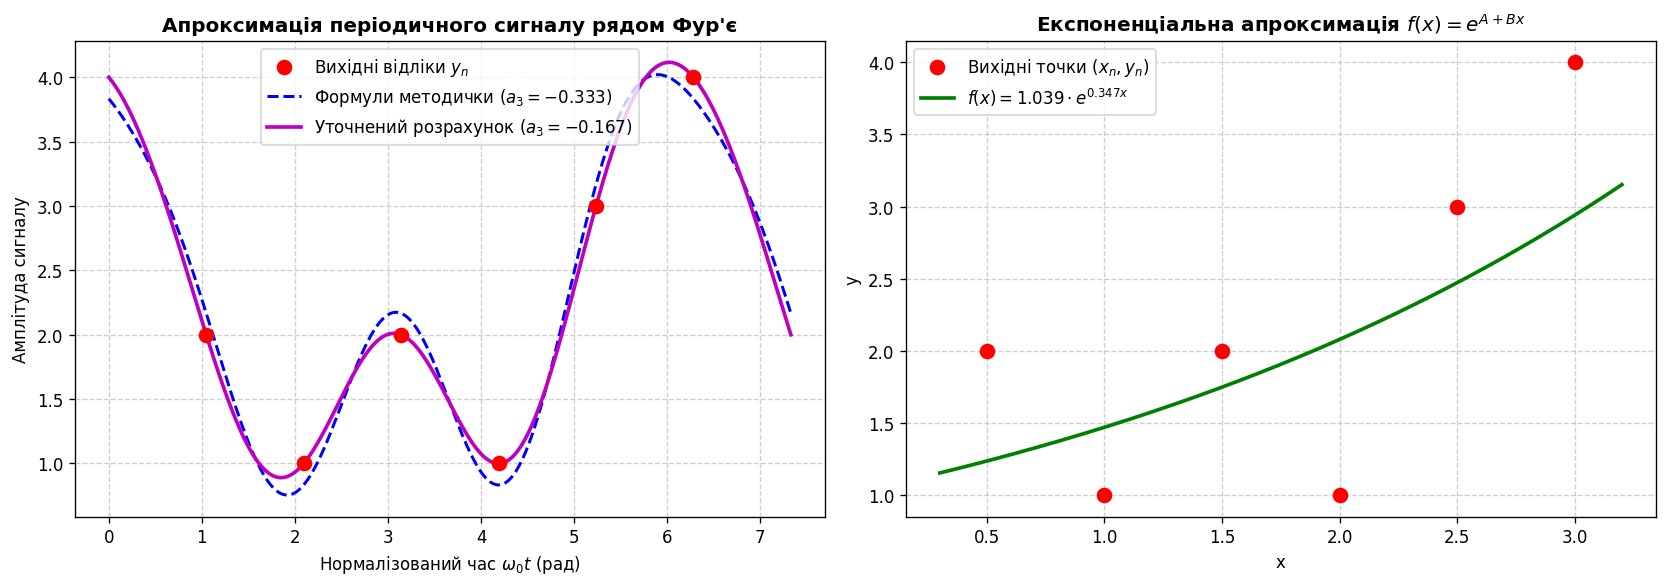

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# ВХІДНІ ДАНІ (Варіант 5)
# ==============================================================================
k_var = 5
n_idx = np.array([1, 2, 3, 4, 5, 6])
y = np.array([2.0, 1.0, 2.0, 1.0, 3.0, 4.0])
N = len(y)

# ==============================================================================
# ЧАСТИНА 1: РЯД ФУР'Є (ДВА ВАРІАНТИ РОЗРАХУНКУ)
# ==============================================================================
# Постійна складова a0 (однакова для обох випадків)
a0 = (2.0 / N) * np.sum(y)

K = N // 2  # K = 3
a_k_method = np.zeros(K)
b_k_method = np.zeros(K)

a_k_exact = np.zeros(K)
b_k_exact = np.zeros(K)

for m in range(1, K + 1):
    arg = m * 2.0 * np.pi * n_idx / N

    # 1. Варіант за методичкою (множник 2/N для всіх гармонік)
    a_k_method[m - 1] = (2.0 / N) * np.sum(y * np.cos(arg))
    b_k_method[m - 1] = (2.0 / N) * np.sum(y * np.sin(arg))

    # 2. Варіант математично точний (для m = N/2 множник 1/N)
    factor = (1.0 / N) if m == K else (2.0 / N)
    a_k_exact[m - 1] = factor * np.sum(y * np.cos(arg))
    b_k_exact[m - 1] = (2.0 / N) * np.sum(y * np.sin(arg))

print("=== КОЕФІЦІЄНТИ РЯДУ ФУР'Є ===")
print(f"a0 = {a0:.4f} (постійна складова a0/2 = {a0/2:.4f})")
print("\nВаріант А (буквально за формулою (48) методички):")
for m in range(1, K + 1):
    print(f"  Гармоніка {m}: a_{m} = {a_k_method[m-1]:.4f}, b_{m} = {b_k_method[m-1]:.4f}")

print("\nВаріант Б (уточнений / гармоніка Найквіста a3 з фактором 1/N):")
for m in range(1, K + 1):
    print(f"  Гармоніка {m}: a_{m} = {a_k_exact[m-1]:.4f}, b_{m} = {b_k_exact[m-1]:.4f}")

def fourier_series(theta, a_coeffs, b_coeffs):
    res = a0 / 2.0
    for m in range(1, K + 1):
        res += a_coeffs[m - 1] * np.cos(m * theta) + b_coeffs[m - 1] * np.sin(m * theta)
    return res

# ==============================================================================
# ЧАСТИНА 2: ЕКСПОНЕНЦІАЛЬНА АПРОКСИМАЦІЯ f(x) = exp(A + B*x)
# ==============================================================================
x_exp = 0.1 * k_var * n_idx  # [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
y_log = np.log(y)

# МНК для прямої ln(y) = A + Bx
M_exp = np.array([
    [N, np.sum(x_exp)],
    [np.sum(x_exp), np.sum(x_exp**2)]
])
V_exp = np.array([
    np.sum(y_log),
    np.sum(x_exp * y_log)
])
A_man, B_man = np.linalg.solve(M_exp, V_exp)

print("\n=== ЕКСПОНЕНЦІАЛЬНА АПРОКСИМАЦІЯ ===")
print(f"A = {A_man:.4f}, B = {B_man:.4f}")
print(f"f(x) = exp({A_man:.4f} + {B_man:.4f}*x) = {np.exp(A_man):.4f} * exp({B_man:.4f}*x)")

# ==============================================================================
# ЧАСТИНА 3: ПОБУДОВА ГРАФІКІВ
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Графік 1: Ряд Фур'є (порівняння двох підходів)
theta_nodes = 2.0 * np.pi * n_idx / N
theta_dense = np.linspace(0, 2.0 * np.pi * (N + 1) / N, 600)

y_fourier_method = fourier_series(theta_dense, a_k_method, b_k_method)
y_fourier_exact = fourier_series(theta_dense, a_k_exact, b_k_exact)

ax1.scatter(theta_nodes, y, color='red', s=70, zorder=6, label='Вихідні відліки $y_n$')
ax1.plot(theta_dense, y_fourier_method, 'b--', linewidth=1.8, label="Формули методички ($a_3 = -0.333$)")
ax1.plot(theta_dense, y_fourier_exact, 'm-', linewidth=2.2, label="Уточнений розрахунок ($a_3 = -0.167$)")
ax1.set_title("Апроксимація періодичного сигналу рядом Фур'є", fontweight='bold')
ax1.set_xlabel(r'Нормалізований час $\omega_0 t$ (рад)')
ax1.set_ylabel('Амплітуда сигналу')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Графік 2: Експоненціальна апроксимація
x_dense = np.linspace(x_exp[0] - 0.2, x_exp[-1] + 0.2, 300)
y_exp_dense = np.exp(A_man + B_man * x_dense)

ax2.scatter(x_exp, y, color='red', s=70, zorder=5, label='Вихідні точки ($x_n, y_n$)')
ax2.plot(x_dense, y_exp_dense, 'g-', linewidth=2.2, label=f'$f(x) = {np.exp(A_man):.3f} \cdot e^{{{B_man:.3f}x}}$')
ax2.set_title('Експоненціальна апроксимація $f(x) = e^{A+Bx}$', fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('lab2_plot_comparison.png', dpi=300)
plt.show()